In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16,6)

In [39]:
file_path = "./buoy/santacruz2025.txt"

# read file ignoring header lines starting with #
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment="#"
)

df.head()

C:\Users\monaz\AppData\Local\Temp\ipykernel_39376\76216891.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,2025,01,31,00,26,999,99.0,99.0.1,0.69,12.50,8.51,294,9999.0,999.0,11.6,999.0.1,99.0.2,99.00
0,2025,1,31,0,56,999,99.0,99.0,0.68,11.11,8.37,290,9999.0,999.0,11.6,999.0,99.0,99.0
1,2025,1,31,1,26,999,99.0,99.0,0.72,11.76,8.73,290,9999.0,999.0,11.6,999.0,99.0,99.0
2,2025,1,31,1,56,999,99.0,99.0,0.70,11.76,8.32,286,9999.0,999.0,11.6,999.0,99.0,99.0
3,2025,1,31,2,26,999,99.0,99.0,0.64,12.50,8.10,286,9999.0,999.0,11.6,999.0,99.0,99.0
4,2025,1,31,2,56,999,99.0,99.0,0.71,12.50,8.51,293,9999.0,999.0,11.6,999.0,99.0,99.0


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "./buoy/santacruz2025.txt"

# Read the first header line manually
with open(file_path, "r") as f:
    first_header = f.readline().strip()

# Build column names from the first header line
columns = first_header.lstrip("#").split()

# Read the actual data, skipping both header lines
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    skiprows=2,
    names=columns
)

print(df.head())
print(df.columns)
df["datetime"] = pd.to_datetime(
    dict(
        year=df["YY"],
        month=df["MM"],
        day=df["DD"],
        hour=df["hh"],
        minute=df["mm"]
    )
)

df = df.sort_values("datetime").reset_index(drop=True)

     YY  MM  DD  hh  mm  WDIR  WSPD   GST  WVHT    DPD   APD  MWD    PRES  \
0  2025   1  31   0  26   999  99.0  99.0  0.69  12.50  8.51  294  9999.0   
1  2025   1  31   0  56   999  99.0  99.0  0.68  11.11  8.37  290  9999.0   
2  2025   1  31   1  26   999  99.0  99.0  0.72  11.76  8.73  290  9999.0   
3  2025   1  31   1  56   999  99.0  99.0  0.70  11.76  8.32  286  9999.0   
4  2025   1  31   2  26   999  99.0  99.0  0.64  12.50  8.10  286  9999.0   

    ATMP  WTMP   DEWP   VIS  TIDE  
0  999.0  11.6  999.0  99.0  99.0  
1  999.0  11.6  999.0  99.0  99.0  
2  999.0  11.6  999.0  99.0  99.0  
3  999.0  11.6  999.0  99.0  99.0  
4  999.0  11.6  999.0  99.0  99.0  
Index(['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
       'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'],
      dtype='object')


C:\Users\monaz\AppData\Local\Temp\ipykernel_39376\2035216400.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [41]:
missing_vals = [99, 99.0, 999, 999.0, 9999, 9999.0]

df["WVHT"] = df["WVHT"].replace(missing_vals, np.nan)
df["DPD"] = df["DPD"].replace(missing_vals, np.nan)

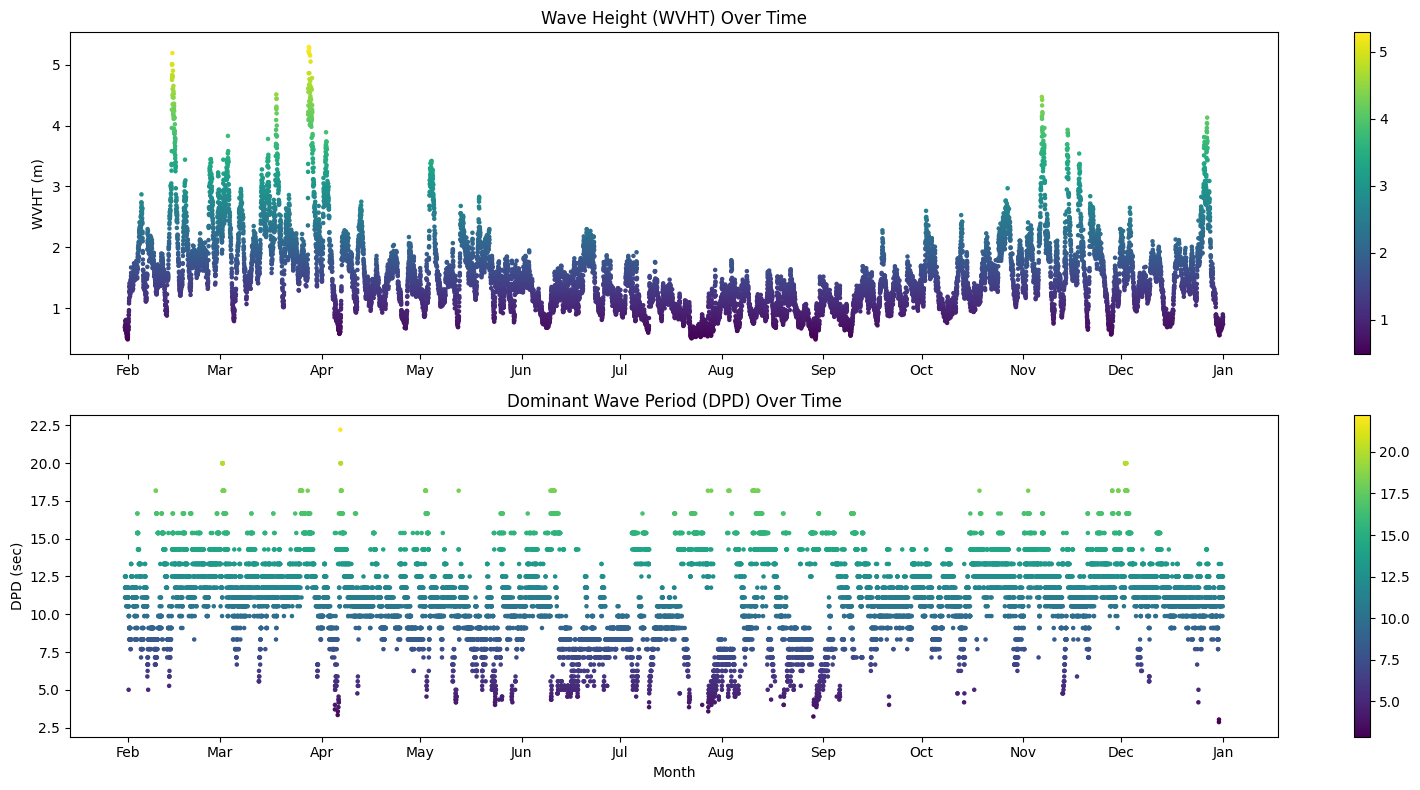

In [42]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(2,1, figsize=(16,8))

# WVHT
sc1 = ax[0].scatter(df["datetime"], df["WVHT"], c=df["WVHT"], s=5)
ax[0].set_title("Wave Height (WVHT) Over Time")
ax[0].set_ylabel("WVHT (m)")
fig.colorbar(sc1, ax=ax[0])

# DPD
sc2 = ax[1].scatter(df["datetime"], df["DPD"], c=df["DPD"], s=5)
ax[1].set_title("Dominant Wave Period (DPD) Over Time")
ax[1].set_ylabel("DPD (sec)")
fig.colorbar(sc2, ax=ax[1])

# Format x-axis to show months
for a in ax:
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

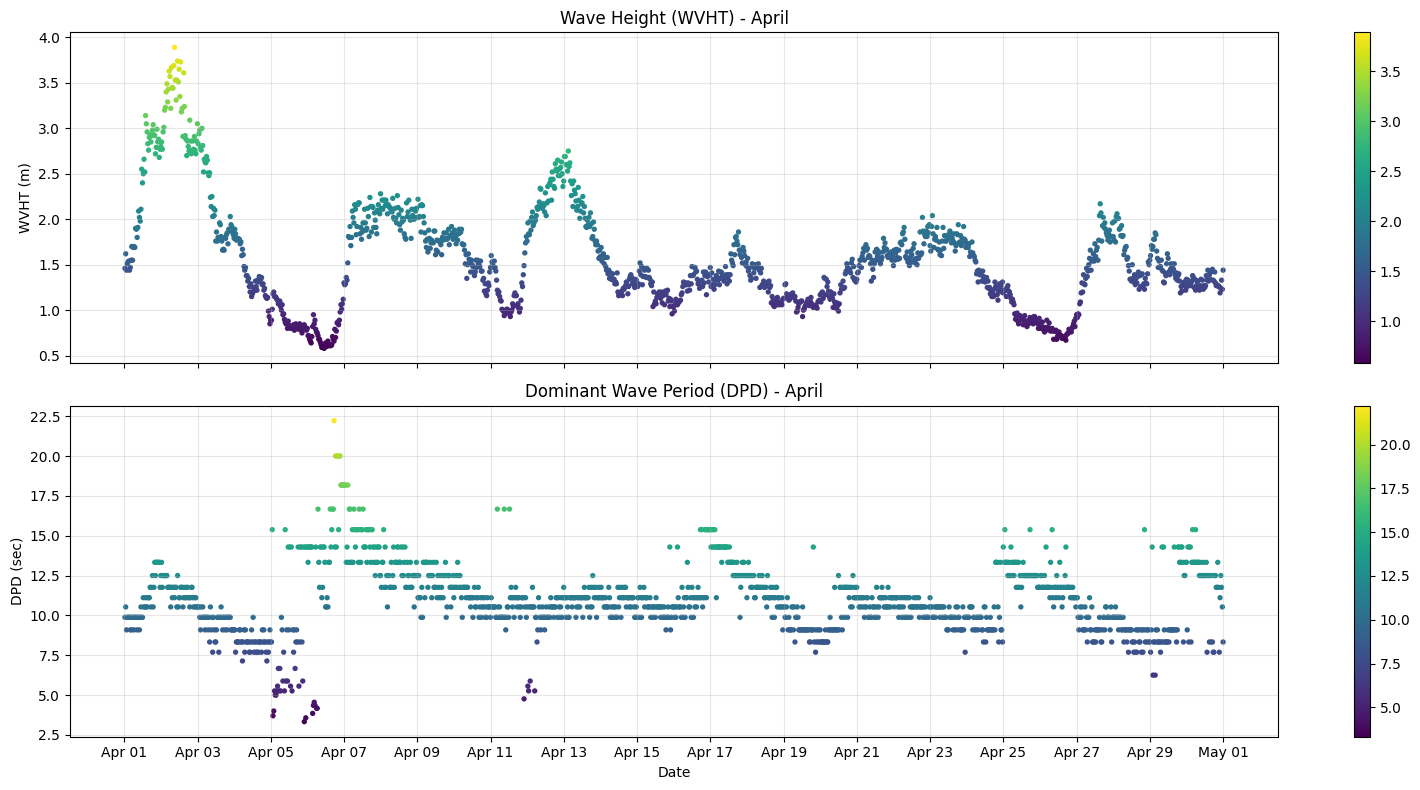

In [43]:
# Plot only one selected month (1=Jan ... 12=Dec)
import calendar
import matplotlib.dates as mdates

selected_month = 4  # change this to the month you want

df_month = df[df["datetime"].dt.month == selected_month].copy()

if df_month.empty:
    print(f"No data found for month {selected_month} ({calendar.month_name[selected_month]}).")
else:
    fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    sc1 = ax[0].scatter(df_month["datetime"], df_month["WVHT"], c=df_month["WVHT"], s=8)
    ax[0].set_title(f"Wave Height (WVHT) - {calendar.month_name[selected_month]}")
    ax[0].set_ylabel("WVHT (m)")
    fig.colorbar(sc1, ax=ax[0])

    sc2 = ax[1].scatter(df_month["datetime"], df_month["DPD"], c=df_month["DPD"], s=8)
    ax[1].set_title(f"Dominant Wave Period (DPD) - {calendar.month_name[selected_month]}")
    ax[1].set_ylabel("DPD (sec)")
    fig.colorbar(sc2, ax=ax[1])

    for a in ax:
        a.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        a.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        a.grid(alpha=0.3)

    ax[1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

In [44]:
import pandas as pd
import numpy as np

# -------------------------
# assuming df is already loaded and datetime already created
# -------------------------

# Clean missing values
missing_vals = [99, 99.0, 99.00, 999, 999.0, 9999, 9999.0]
for col in ["WVHT", "DPD", "MWD"]:
    df[col] = df[col].replace(missing_vals, np.nan)

# keep only what you care about
table_df = df[["datetime", "WVHT", "DPD", "MWD"]].copy()

# optional: round values for display
table_df["WVHT"] = table_df["WVHT"].round(2)
table_df["DPD"] = table_df["DPD"].round(2)
table_df["MWD"] = table_df["MWD"].round(0)

# If full year is too huge, preview first 200 rows
preview_df = table_df.head(200)

styled = (
    preview_df.style
    .format({
        "datetime": lambda x: x.strftime("%Y-%m-%d %H:%M"),
        "WVHT": "{:.2f}",
        "DPD": "{:.2f}",
        "MWD": "{:.0f}"
    })
    .background_gradient(subset=["WVHT"], cmap="YlGnBu")
    .background_gradient(subset=["DPD"], cmap="YlOrRd")
    .background_gradient(subset=["MWD"], cmap="PuRd")
)

In [45]:
styled

,datetime,WVHT,DPD,MWD
0,2025-01-31 00:26,0.69,12.50,294
1,2025-01-31 00:56,0.68,11.11,290
2,2025-01-31 01:26,0.72,11.76,290
3,2025-01-31 01:56,0.70,11.76,286
4,2025-01-31 02:26,0.64,12.50,286
5,2025-01-31 02:56,0.71,12.50,293
6,2025-01-31 03:26,0.72,11.76,286
7,2025-01-31 03:56,0.68,11.11,287
8,2025-01-31 04:26,0.79,11.76,291
9,2025-01-31 04:56,0.79,11.76,290


In [46]:
heat_df = df[["datetime","WVHT","DPD"]].copy()

heat_df["date"] = heat_df["datetime"].dt.date
heat_df["time"] = heat_df["datetime"].dt.strftime("%H:%M")

wvht_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="WVHT",
    aggfunc="mean"
)

dpd_grid = heat_df.pivot_table(
    index="date",
    columns="time",
    values="DPD",
    aggfunc="mean"
)

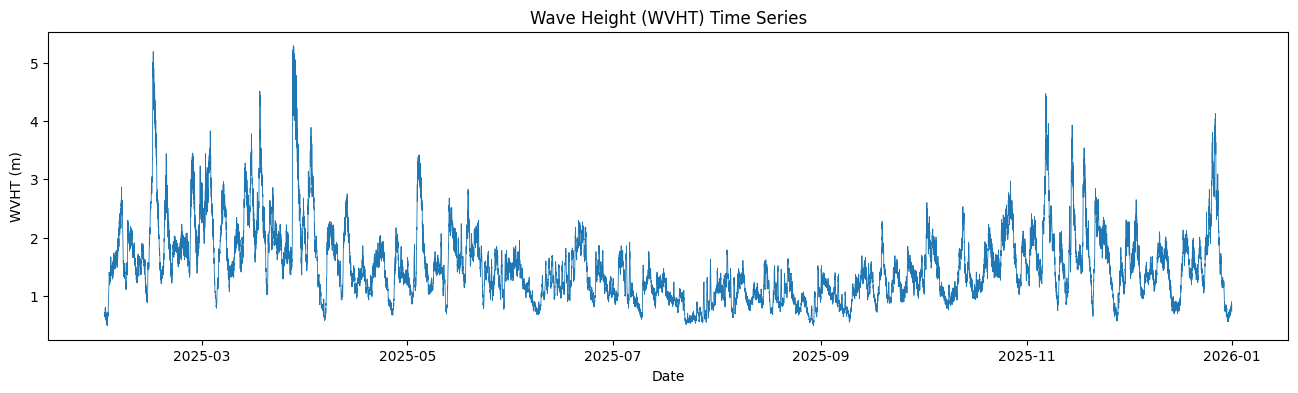

In [47]:
plt.figure(figsize=(16,4))

plt.plot(df["datetime"], df["WVHT"], linewidth=0.6)

plt.title("Wave Height (WVHT) Time Series")
plt.ylabel("WVHT (m)")
plt.xlabel("Date")

plt.show()

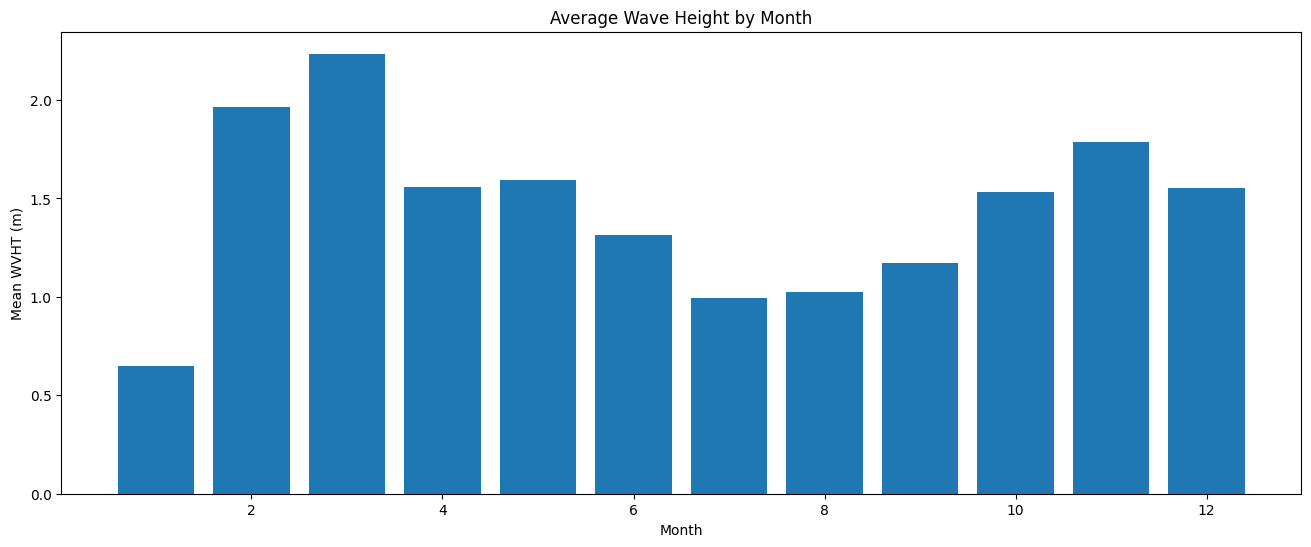

In [48]:
df["month"] = df["datetime"].dt.month

monthly = df.groupby("month")["WVHT"].mean()

plt.bar(monthly.index, monthly.values)

plt.xlabel("Month")
plt.ylabel("Mean WVHT (m)")
plt.title("Average Wave Height by Month")

plt.show()

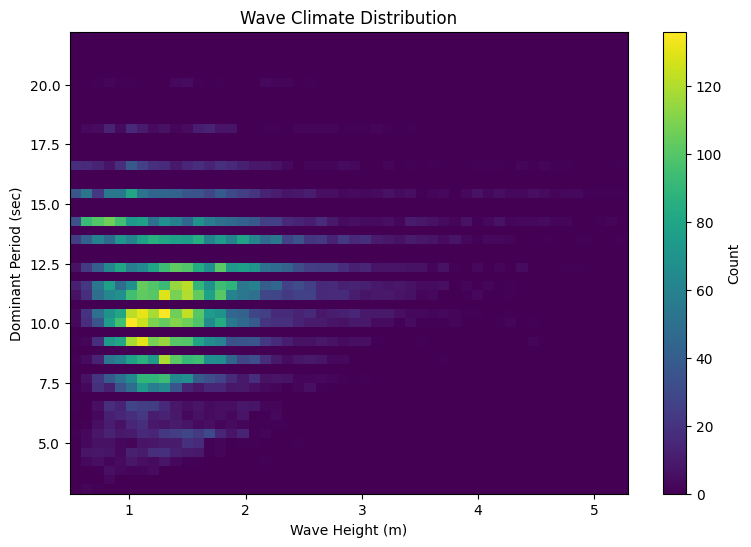

In [49]:
plt.figure(figsize=(9,6))

plt.hist2d(df["WVHT"], df["DPD"], bins=50)

plt.xlabel("Wave Height (m)")
plt.ylabel("Dominant Period (sec)")
plt.title("Wave Climate Distribution")

plt.colorbar(label="Count")

plt.show()

## Daily Wave-Energy Classification (Calm / Mild / Active)

This section uses both wave height (`WVHT`) and dominant period (`DPD`) to classify each day.

Energy proxy used:
`energy_proxy = WVHT^2 * DPD`

Why this helps:
- `WVHT` captures wave size
- `DPD` captures wave period (longer-period swell carries more energy)
- Combining both gives a better "active vs calm" signal than height alone

In [50]:
# Build daily metrics and classify days
import pandas as pd
import numpy as np

work = df[["datetime", "WVHT", "DPD"]].copy()
work = work.dropna(subset=["WVHT", "DPD"]).copy()
work["date"] = work["datetime"].dt.date

# Wave-energy proxy (relative index, not absolute physical power units)
work["energy_proxy"] = (work["WVHT"] ** 2) * work["DPD"]

daily = (
    work.groupby("date", as_index=False)
    .agg(
        wvht_mean=("WVHT", "mean"),
        wvht_p90=("WVHT", lambda s: s.quantile(0.90)),
        wvht_max=("WVHT", "max"),
        dpd_mean=("DPD", "mean"),
        dpd_p90=("DPD", lambda s: s.quantile(0.90)),
        energy_mean=("energy_proxy", "mean"),
        energy_p90=("energy_proxy", lambda s: s.quantile(0.90)),
        n_obs=("energy_proxy", "size"),
    )
)

# Use quantiles so classes adapt to this station/year distribution
q_low = daily["energy_mean"].quantile(0.33)
q_high = daily["energy_mean"].quantile(0.66)

bins = [-np.inf, q_low, q_high, np.inf]
labels = ["calm", "mild", "active"]
daily["energy_class"] = pd.cut(daily["energy_mean"], bins=bins, labels=labels, include_lowest=True)

# Optional sea-state class from height only (WMO-like quick interpretation)
def wmo_height_class(h):
    if pd.isna(h):
        return np.nan
    if h < 0.1:
        return "Calm"
    if h < 0.5:
        return "Smooth"
    if h < 1.25:
        return "Slight"
    if h < 2.5:
        return "Moderate"
    if h < 4.0:
        return "Rough"
    return "Very rough+"

daily["height_state"] = daily["wvht_mean"].apply(wmo_height_class)

# Make datetime for plotting
DailyDate = pd.to_datetime(daily["date"])
daily["date_dt"] = DailyDate

print("Daily energy thresholds (energy_mean):")
print(f"  calm <= {q_low:.3f}")
print(f"  mild: {q_low:.3f} to {q_high:.3f}")
print(f"  active > {q_high:.3f}")

daily.head(10)

Daily energy thresholds (energy_mean):
  calm <= 14.865
  mild: 14.865 to 30.490
  active > 30.490


,date,wvht_mean,wvht_p90,wvht_max,dpd_mean,dpd_p90,energy_mean,energy_p90,n_obs,energy_class,height_state,date_dt
0,2025-01-31,0.646383,0.766,0.81,11.556170,12.500,4.938807,6.799632,47,calm,Slight,2025-01-31
1,2025-02-01,1.209167,1.492,1.67,9.586458,12.500,14.835542,26.610875,48,calm,Slight,2025-02-01
2,2025-02-02,1.491667,1.643,1.74,11.383333,12.500,25.373157,30.302392,48,mild,Moderate,2025-02-02
3,2025-02-03,1.638750,1.783,1.91,11.555417,15.380,31.598053,48.894712,48,active,Moderate,2025-02-03
4,2025-02-04,2.197500,2.444,2.65,12.927083,14.290,62.010472,73.327978,48,active,Moderate,2025-02-04
5,2025-02-05,1.930625,2.640,2.87,9.429375,11.305,35.897422,58.722752,48,active,Moderate,2025-02-05
6,2025-02-06,1.461875,2.000,2.30,10.621667,11.982,22.081445,28.942047,48,mild,Moderate,2025-02-06
7,2025-02-07,2.006875,2.146,2.27,8.226667,9.090,33.207093,38.686949,48,active,Moderate,2025-02-07
8,2025-02-08,1.836875,2.070,2.16,8.651667,9.090,29.488475,38.312805,48,mild,Moderate,2025-02-08
9,2025-02-09,1.454583,1.613,1.67,9.524375,16.670,19.616345,27.570180,48,mild,Moderate,2025-02-09


C:\Users\monaz\AppData\Local\Temp\ipykernel_39376\1037019165.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cls, sub in daily.groupby("energy_class"):
C:\Users\monaz\AppData\Local\Temp\ipykernel_39376\1037019165.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cls, sub in daily.groupby("energy_class"):


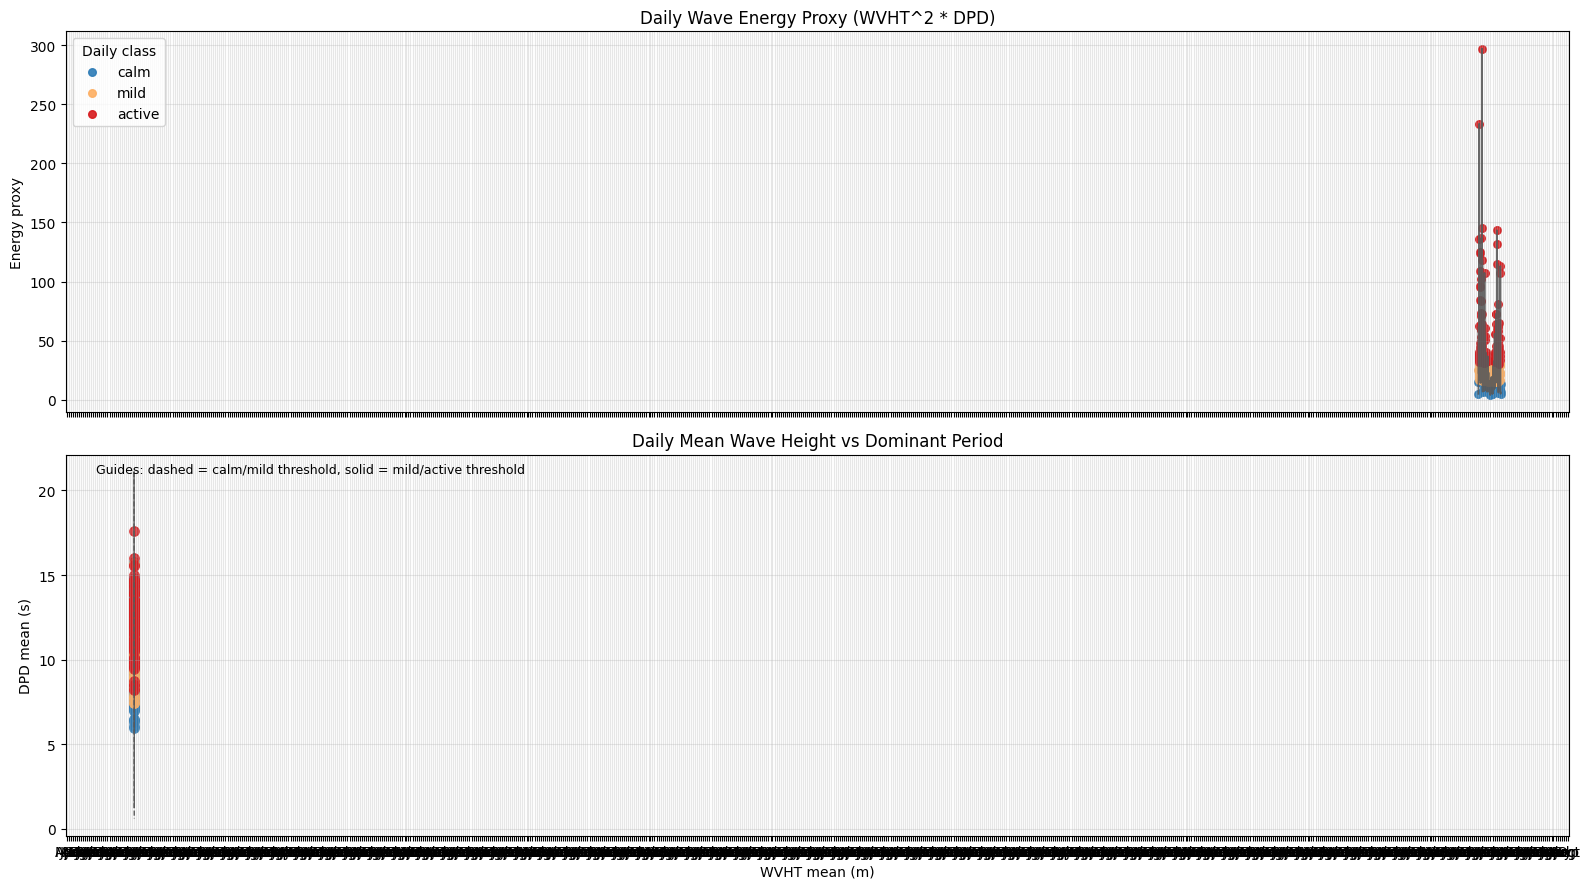

In [ ]:
# Visualization 1 (fixed): clear daily timeline + WVHT/DPD phase-space
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

class_colors = {"calm": "#2c7bb6", "mild": "#fdae61", "active": "#d7191c"}

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# Left panel: daily energy timeline (date axis)
ax0 = axes[0]
ax0.plot(daily["date_dt"], daily["energy_mean"], color="0.35", linewidth=1.0, alpha=0.7)
for cls, sub in daily.groupby("energy_class"):
    ax0.scatter(
        sub["date_dt"],
        sub["energy_mean"],
        s=32,
        color=class_colors.get(str(cls), "0.5"),
        label=str(cls),
        alpha=0.9,
    )

ax0.axhline(q_low, color="0.4", linestyle="--", linewidth=1.0, label="calm/mild threshold")
ax0.axhline(q_high, color="0.2", linestyle="-", linewidth=1.0, label="mild/active threshold")
ax0.set_title("Daily Wave Energy Proxy (WVHT^2 * DPD)")
ax0.set_xlabel("Date")
ax0.set_ylabel("Energy proxy")
ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax0.grid(alpha=0.3)
ax0.legend(title="Daily class", loc="upper left")

# Right panel: daily WVHT-DPD space (numeric axes)
ax1 = axes[1]
sc = ax1.scatter(
    daily["wvht_mean"],
    daily["dpd_mean"],
    c=daily["energy_mean"],
    cmap="YlOrRd",
    s=np.clip(daily["energy_mean"] * 1.2, 20, 200),
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)

# Iso-energy guide curves for thresholds
h_grid = np.linspace(max(0.05, float(daily["wvht_mean"].min()) * 0.8), float(daily["wvht_mean"].max()) * 1.1, 200)
for E, ls, txt in [(q_low, "--", "calm/mild"), (q_high, "-", "mild/active")]:
    p_curve = E / (h_grid ** 2)
    p_curve = np.clip(p_curve, 0, daily["dpd_mean"].max() * 1.2)
    ax1.plot(h_grid, p_curve, ls=ls, color="0.25", linewidth=1.2)
    ax1.text(h_grid[-1], p_curve[-1], f" {txt}", fontsize=8, va="center")

ax1.set_title("Daily Mean Wave Height vs Dominant Period")
ax1.set_xlabel("WVHT mean (m)")
ax1.set_ylabel("DPD mean (s)")
ax1.grid(alpha=0.3)
fig.colorbar(sc, ax=ax1, label="Energy proxy")

plt.show()

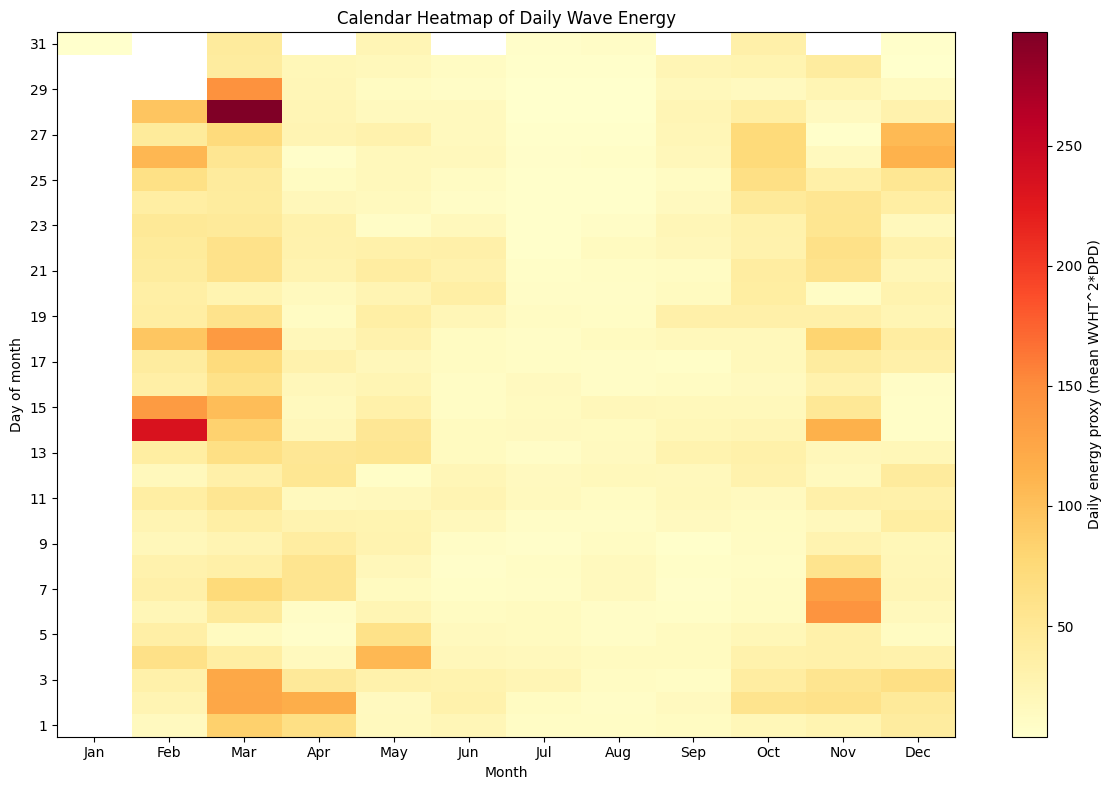

Top 10 most active days:


,date,energy_mean,energy_class,wvht_mean,dpd_mean,height_state,n_obs
56,2025-03-28,297.118645,active,4.431250,15.003333,Very rough+,48
14,2025-02-14,233.602172,active,4.089583,12.834375,Very rough+,48
57,2025-03-29,145.123546,active,3.260417,13.011042,Rough,48
279,2025-11-06,143.446767,active,3.150625,13.214167,Rough,48
46,2025-03-18,136.987400,active,3.457083,11.487708,Rough,48
15,2025-02-15,135.977735,active,3.182917,12.758542,Rough,48
280,2025-11-07,131.503100,active,3.030208,13.437917,Rough,48
30,2025-03-02,125.231890,active,2.821667,15.572708,Rough,48
31,2025-03-03,123.935842,active,3.083958,12.735833,Rough,48
61,2025-04-02,118.334679,active,3.186875,11.493958,Rough,48


Top 10 calmest days:


,date,energy_mean,energy_class,wvht_mean,dpd_mean,height_state,n_obs
178,2025-07-28,3.911098,calm,0.800417,6.428750,Slight,48
179,2025-07-29,4.868449,calm,0.902500,5.991667,Slight,48
333,2025-12-30,4.926703,calm,0.710417,9.818542,Slight,48
0,2025-01-31,4.938807,calm,0.646383,11.556170,Slight,47
209,2025-08-28,4.939908,calm,0.618542,13.006875,Slight,48
210,2025-08-29,4.972579,calm,0.661250,12.245000,Slight,48
206,2025-08-25,5.210167,calm,0.778542,8.468333,Slight,48
172,2025-07-22,5.247954,calm,0.699792,11.943958,Slight,48
221,2025-09-09,5.337459,calm,0.684375,11.094167,Slight,48
211,2025-08-30,5.395109,calm,0.853542,8.159167,Slight,48


In [52]:
# Visualization 2: Calendar-style heatmap + top/bottom day tables
import calendar

daily_plot = daily.copy()
daily_plot["month"] = pd.to_datetime(daily_plot["date"]).dt.month
daily_plot["day"] = pd.to_datetime(daily_plot["date"]).dt.day

energy_cal = daily_plot.pivot(index="day", columns="month", values="energy_mean")

plt.figure(figsize=(12, 8))
plt.imshow(energy_cal, aspect="auto", origin="lower", cmap="YlOrRd")
plt.colorbar(label="Daily energy proxy (mean WVHT^2*DPD)")

plt.xticks(ticks=np.arange(12), labels=[calendar.month_abbr[i] for i in range(1, 13)])
plt.yticks(ticks=np.arange(0, 31, 2), labels=np.arange(1, 32, 2))
plt.xlabel("Month")
plt.ylabel("Day of month")
plt.title("Calendar Heatmap of Daily Wave Energy")
plt.tight_layout()
plt.show()

summary_cols = ["date", "energy_mean", "energy_class", "wvht_mean", "dpd_mean", "height_state", "n_obs"]

print("Top 10 most active days:")
display(daily.sort_values("energy_mean", ascending=False)[summary_cols].head(10))

print("Top 10 calmest days:")
display(daily.sort_values("energy_mean", ascending=True)[summary_cols].head(10))